In [ ]:
# Deep Learning Regression: Architecture Comparison (PyTorch)

# Phase 1: Environment Setup & Data Preparation
# In this notebook, we replicate the California Housing architecture comparison using PyTorch. We start by preparing the environment, 
# applying standard scaling, and reducing dimensionality using PCA.

In [1]:
# --- 1. Core Libraries ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# --- 2. PyTorch Libraries ---
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, TensorDataset

# --- 3. Machine Learning Tools ---
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Метрики
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [2]:
# --- 4. Load & Split Dataset ---
california = fetch_california_housing(as_frame=True)
df = california.frame 

X = df.drop("MedHouseVal", axis=1)
y = df["MedHouseVal"]

# train (70%), validation (15%), test (15%)
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train:", X_train.shape, y_train.shape)
print("Val:", X_val.shape, y_val.shape)
print("Test:", X_test.shape, y_test.shape)

Explained variance ratio (5 components): [0.25332065 0.23393326 0.15935984 0.12964566 0.12550435]
Total variance explained: 0.901763752448135


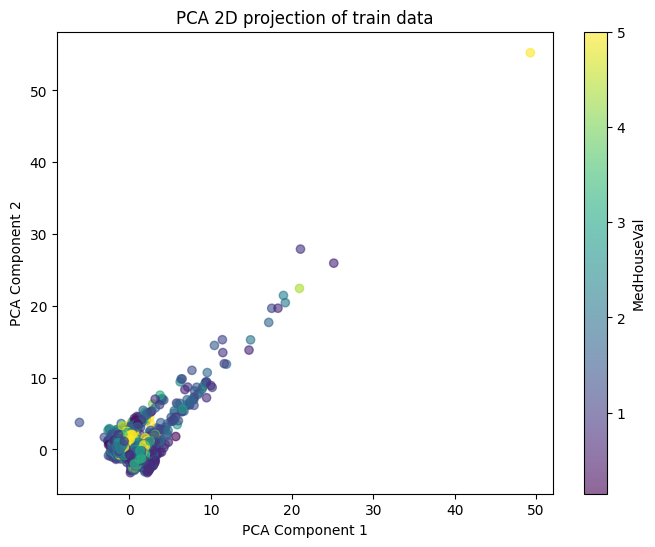

In [5]:
# --- 5. Scaling & PCA (5 Components) ---
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

pca = PCA(n_components=5)
X_train_pca = pca.fit_transform(X_train)
X_val_pca = pca.transform(X_val)
X_test_pca = pca.transform(X_test)

print("Explained variance ratio (5 components):", pca.explained_variance_ratio_)
print("Total variance explained:", sum(pca.explained_variance_ratio_))

# Візуалізація перших 2 компонент
plt.figure(figsize=(8,6))
plt.scatter(X_train_pca[:,0], X_train_pca[:,1], c=y_train, cmap='viridis', alpha=0.6)
plt.colorbar(label='MedHouseVal')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('PCA 2D projection of train data')
plt.show()

In [ ]:
# Phase 2: PyTorch Tensors & DataLoaders
# Unlike TensorFlow, PyTorch requires explicit conversion of NumPy arrays into Tensors and 
# the configuration of DataLoaders to handle batch processing efficiently.

In [6]:
# --- 1. Convert Arrays to PyTorch Tensors ---

X_train_tensor = torch.tensor(X_train_pca, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

X_val_tensor = torch.tensor(X_val_pca, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val.values, dtype=torch.float32).view(-1,1)

X_test_tensor = torch.tensor(X_test_pca, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

# --- 2. Initialize DataLoaders ---
batch_size = 32

train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset   = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=batch_size)
test_loader  = DataLoader(test_dataset, batch_size=batch_size)

In [ ]:
# Phase 3: Neural Network Architectures Definition
# We define the exact same architectures using PyTorch's `nn.Module`. 
# L2 Regularization will be handled dynamically inside the Adam optimizer via `weight_decay`.

In [7]:
# --- 1. Basic Model (ReLU) ---
class BasicReLU(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32,1)
    def forward(self,x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.out(x)
        return x

# --- 2. Basic Model (LeakyReLU) ---
class BasicLeakyReLU(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim, 64)
        self.fc2 = nn.Linear(64, 32)
        self.out = nn.Linear(32,1)
        self.leaky = nn.LeakyReLU(0.1)
    def forward(self,x):
        x = self.leaky(self.fc1(x))
        x = self.leaky(self.fc2(x))
        x = self.out(x)
        return x

# --- 3. Advanced Model (ReLU + BatchNorm + Dropout) ---
class AdvancedReLU(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim,128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128,64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64,32)
        self.dropout = nn.Dropout(0.3)
        self.out = nn.Linear(32,1)
    def forward(self,x):
        x = F.relu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.relu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.relu(self.fc3(x))
        x = self.out(x)
        return x

# --- 4. Advanced Model (GELU + BatchNorm + Dropout) ---
class AdvancedGELU(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.fc1 = nn.Linear(input_dim,128)
        self.bn1 = nn.BatchNorm1d(128)
        self.fc2 = nn.Linear(128,64)
        self.bn2 = nn.BatchNorm1d(64)
        self.fc3 = nn.Linear(64,32)
        self.dropout = nn.Dropout(0.3)
        self.out = nn.Linear(32,1)
    def forward(self,x):
        x = F.gelu(self.bn1(self.fc1(x)))
        x = self.dropout(x)
        x = F.gelu(self.bn2(self.fc2(x)))
        x = self.dropout(x)
        x = F.gelu(self.fc3(x))
        x = self.out(x)
        return x

In [ ]:
# Phase 4: Custom PyTorch Training Loop
# We define a robust training loop that handles forward propagation, backpropagation, metric calculation (MSE/MAE), and 
# model evaluation dynamically across epochs.

In [8]:
def train_model(model, train_loader, val_loader, epochs=15, lr=0.001, device='cpu'):
    model.to(device)
    # L2 Regularization is implemented via weight_decay in Adam
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=0.001) 
    criterion = nn.MSELoss()
    
    history = {'train_mae':[], 'val_mae':[], 'train_mse':[], 'val_mse':[]}
    
    for epoch in range(epochs):
        # --- Training Phase ---
        model.train()
        train_losses = []
        train_mae = []
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            train_mae.append(mean_absolute_error(yb.cpu().detach().numpy(), pred.cpu().detach().numpy()))
            
        # --- Validation Phase ---
        model.eval()
        val_losses = []
        val_mae = []
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                pred = model(xb)
                loss = criterion(pred, yb)
                val_losses.append(loss.item())
                val_mae.append(mean_absolute_error(yb.cpu().numpy(), pred.cpu().numpy()))
                
        # --- Record History ---
        history['train_mse'].append(np.mean(train_losses))
        history['val_mse'].append(np.mean(val_losses))
        history['train_mae'].append(np.mean(train_mae))
        history['val_mae'].append(np.mean(val_mae))
        print(f"Epoch {epoch+1}/{epochs}: Train MAE={history['train_mae'][-1]:.4f}, Val MAE={history['val_mae'][-1]:.4f}")
    return model, history


In [9]:
# --- Execute Training for All Models ---
input_dim = X_train_pca.shape[1]
epochs = 15

models = {
    "Basic ReLU": BasicReLU(input_dim),
    "Basic LeakyReLU": BasicLeakyReLU(input_dim),
    "Advanced ReLU": AdvancedReLU(input_dim),
    "Advanced GELU": AdvancedGELU(input_dim)
}

histories = {}
device = 'cuda' if torch.cuda.is_available() else 'cpu'

for name, model in models.items():
    print(f"\nTraining {name}")
    trained_model, history = train_model(model, train_loader, val_loader, epochs=epochs, device=device)
    histories[name] = history
    models[name] = trained_model  # заміна на натреновану модель



Training Basic ReLU
Epoch 1/15: Train MAE=0.7419, Val MAE=0.6200
Epoch 2/15: Train MAE=0.6025, Val MAE=0.5931
Epoch 3/15: Train MAE=0.5928, Val MAE=0.6056
Epoch 4/15: Train MAE=0.5867, Val MAE=0.5850
Epoch 5/15: Train MAE=0.5786, Val MAE=0.5721
Epoch 6/15: Train MAE=0.5698, Val MAE=0.5622
Epoch 7/15: Train MAE=0.5653, Val MAE=0.5535
Epoch 8/15: Train MAE=0.5566, Val MAE=0.5447
Epoch 9/15: Train MAE=0.5526, Val MAE=0.5394
Epoch 10/15: Train MAE=0.5510, Val MAE=0.5548
Epoch 11/15: Train MAE=0.5483, Val MAE=0.5511
Epoch 12/15: Train MAE=0.5473, Val MAE=0.5358
Epoch 13/15: Train MAE=0.5443, Val MAE=0.5476
Epoch 14/15: Train MAE=0.5442, Val MAE=0.5366
Epoch 15/15: Train MAE=0.5436, Val MAE=0.5467

Training Basic LeakyReLU
Epoch 1/15: Train MAE=0.7760, Val MAE=0.6477
Epoch 2/15: Train MAE=0.6178, Val MAE=0.6166
Epoch 3/15: Train MAE=0.6012, Val MAE=0.6029
Epoch 4/15: Train MAE=0.5912, Val MAE=0.5803
Epoch 5/15: Train MAE=0.5841, Val MAE=0.5999
Epoch 6/15: Train MAE=0.5780, Val MAE=0.5687
Ep

In [ ]:
# Phase 5: Test Set Evaluation & Learning Curves
# Finally, we evaluate all trained models on the unseen Test set to measure their true generalization capabilities and 
# plot the learning curves for comparative analysis.

In [10]:
# --- 1. Evaluate Models on Test Set ---
for name, model in models.items():
    model.eval()
    y_pred = []
    with torch.no_grad():
        for xb, _ in test_loader:
            xb = xb.to(device)
            pred = model(xb)
            y_pred.extend(pred.cpu().numpy().ravel())
    y_true = y_test.values
    mae_val = mean_absolute_error(y_true, y_pred)
    mse_val = mean_squared_error(y_true, y_pred)
    rmse_val = np.sqrt(mse_val)
    r2 = r2_score(y_true, y_pred)
    print(f"{name}: MAE={mae_val:.4f}, MSE={mse_val:.4f}, RMSE={rmse_val:.4f}, R2={r2:.4f}")


Basic ReLU: MAE=0.5369, MSE=0.5421, RMSE=0.7363, R2=0.5900
Basic LeakyReLU: MAE=0.5277, MSE=0.5568, RMSE=0.7462, R2=0.5789
Advanced ReLU: MAE=0.5734, MSE=0.6286, RMSE=0.7929, R2=0.5246
Advanced GELU: MAE=0.5524, MSE=0.5678, RMSE=0.7535, R2=0.5706


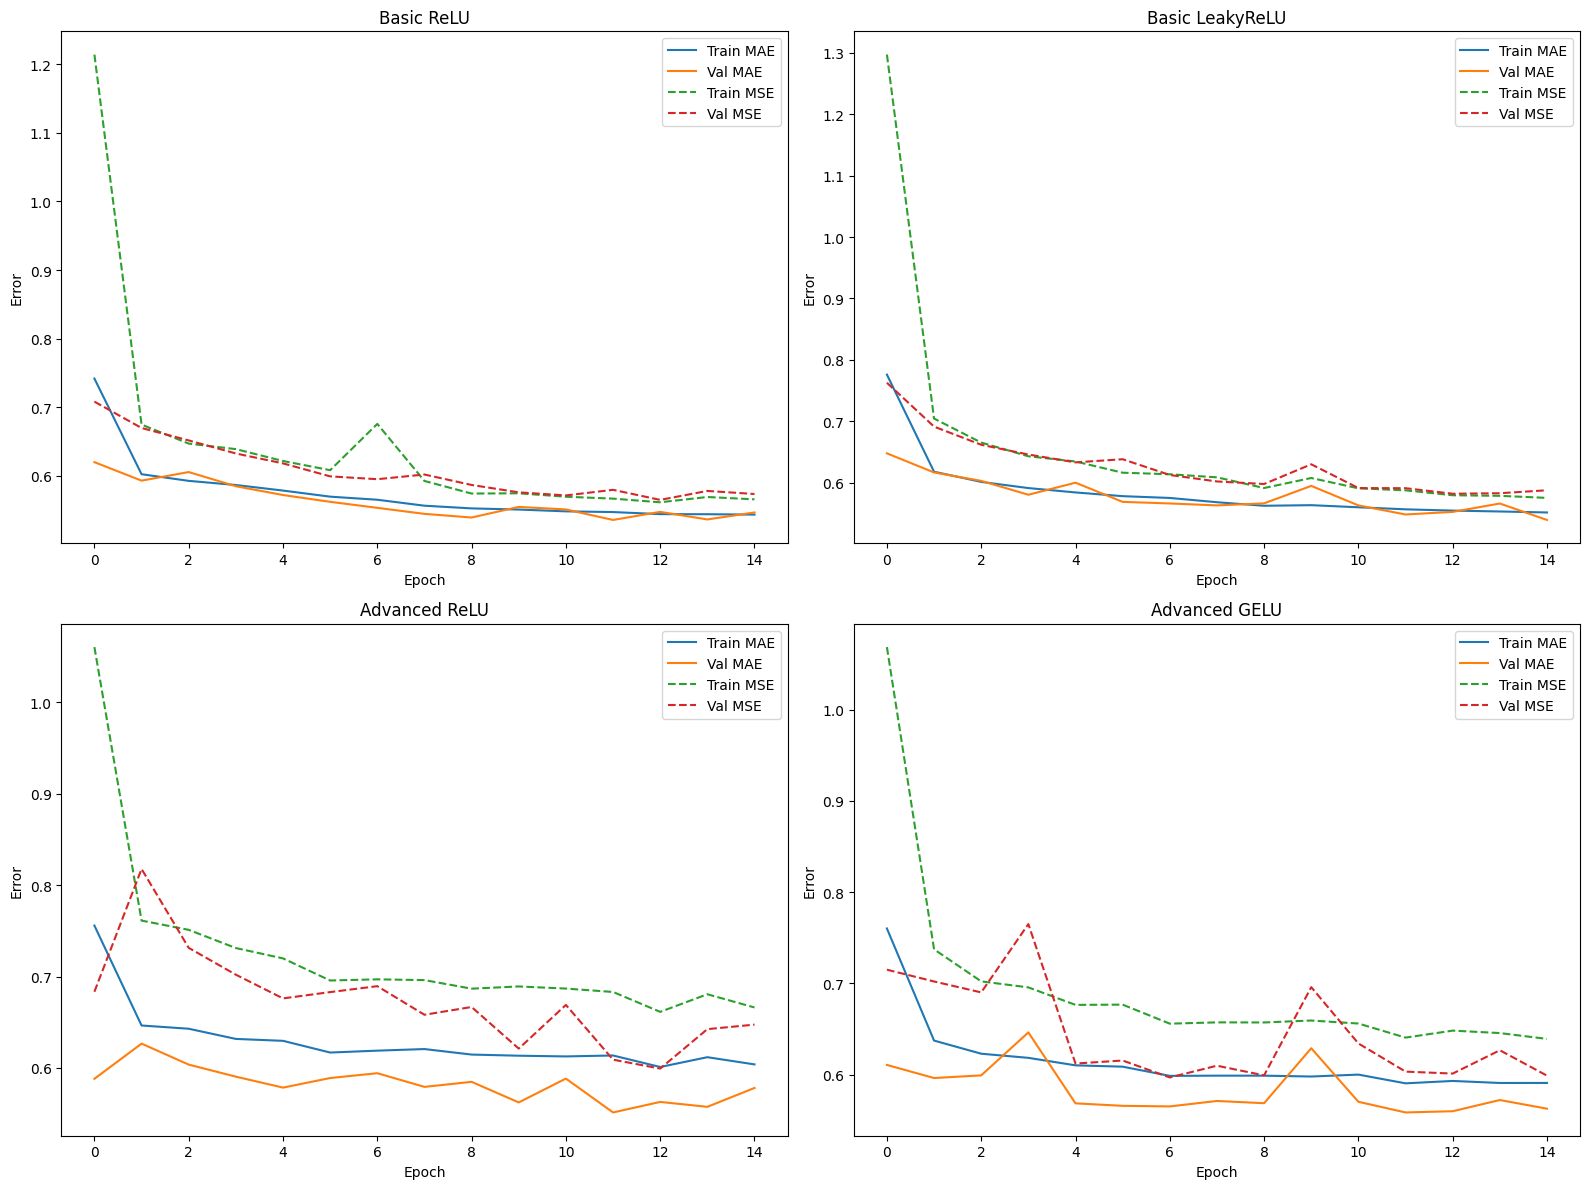

In [11]:
# --- 2. Plot Learning Curves ---
plt.figure(figsize=(16,12))
for i, (name, history) in enumerate(histories.items(),1):
    plt.subplot(2,2,i)
    plt.plot(history['train_mae'], label='Train MAE')
    plt.plot(history['val_mae'], label='Val MAE')
    plt.plot(history['train_mse'],'--', label='Train MSE')
    plt.plot(history['val_mse'],'--', label='Val MSE')
    plt.title(name)
    plt.xlabel('Epoch')
    plt.ylabel('Error')
    plt.legend()
plt.tight_layout()
plt.show()
